# RSSM Experiment on Colab
Runs the original DreamerV1 RSSM world model on `Pendulum-v1`.

## 1. Mount Google Drive (optional, to persist logs)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Clone the repo

In [ ]:
import os

REPO_URL = "https://github.com/Haollll/dreamer.git"
BRANCH   = "linux-colab-support"
WORKDIR  = "/content/dreamer"

if not os.path.exists(WORKDIR):
    !git clone -b {BRANCH} {REPO_URL} {WORKDIR}
else:
    !git -C {WORKDIR} pull origin {BRANCH}

os.chdir(WORKDIR)
print("Working directory:", os.getcwd())

## 3. Install dependencies

In [ ]:
# Force legacy Keras 2 before TF is imported to avoid Keras 3 API breaks.
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

!pip install -q tf-keras tensorflow-probability==0.24.0
!pip install -q "gym==0.25.2" Pillow matplotlib

## 4. Verify GPU

In [4]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print("GPUs:", gpus if gpus else "None — running on CPU")

GPUs: None — running on CPU


## 5. Set log directory
Change `USE_DRIVE` to `True` to persist logs to Google Drive across sessions.

In [5]:
USE_DRIVE = False  # set True to save logs to Drive

if USE_DRIVE:
    LOGDIR = "/content/drive/MyDrive/dreamer_logs/rssm"
else:
    LOGDIR = "/content/dreamer/logs/rssm"

!mkdir -p {LOGDIR}
print("Log directory:", LOGDIR)

Log directory: /content/dreamer/logs/rssm


## 6. Train RSSM

In [6]:
!python dreamer.py \
    --task         gym_Pendulum-v1 \
    --world_model  rssm \
    --logdir       {LOGDIR} \
    --steps        50000 \
    --prefill      1000 \
    --time_limit   200 \
    --action_repeat 2 \
    --eval_every   5000 \
    --seed         42 \
    --precision    16 \
    --log_images   False

Traceback (most recent call last):
  File "/content/dreamer/dreamer.py", line 15, in <module>
    from tensorflow.keras.mixed_precision import experimental as prec
ImportError: cannot import name 'experimental' from 'tensorflow.keras.mixed_precision' (/usr/local/lib/python3.11/dist-packages/keras/api/_v2/keras/mixed_precision/__init__.py)


## 7. Plot results

In [7]:
RESULTS_DIR = LOGDIR.replace("/rssm", "/results")
!mkdir -p {RESULTS_DIR}

!python evaluate.py \
    --logdirs      {LOGDIR} \
    --labels       RSSM \
    --world_models rssm \
    --outdir       {RESULTS_DIR} \
    --horizon      5 \
    --mse_transitions 1000

/content/dreamer/evaluate.py:278: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
Saved reward curves → /content/dreamer/logs/results/reward_curves.png

Computing prediction MSE for RSSM (rssm)...
  Loaded 500 transitions from /content/dreamer/logs/rssm/episodes
  RSSM MSE in obs-space skipped (requires image decoder).

All plots saved to /content/dreamer/logs/results/


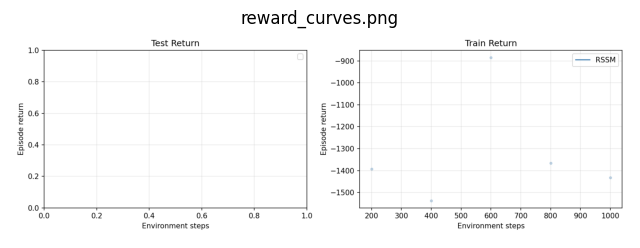

In [8]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

for fname in ["reward_curves.png", "prediction_mse.png"]:
    fpath = os.path.join(RESULTS_DIR, fname)
    if os.path.exists(fpath):
        plt.figure(figsize=(8, 4))
        plt.imshow(mpimg.imread(fpath))
        plt.axis('off')
        plt.title(fname)
        plt.show()